# Phase 1.5 Deep Exploration: The Archetypes of Failure
## Unsupervised Machine Learning (K-Means Clustering) on the Unified OED Pipeline

In this notebook, we move beyond predicting test scores to mathematically defining the **structural archetypes** of the Italian school system. We will use Unsupervised Machine Learning (K-Means) to group schools based on their infrastructural decay, teacher precarity, and INVALSI outcomes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('c:/Users/Dell/Documents/Antigravity/Italienation').resolve()


In [2]:
# 1. Base Schools
scuole = pd.read_parquet(ROOT / 'local_data/Scuola_in_chiaro/scuole/SCUANAGRAFESTAT.parquet')
scuole = scuole[['CODICESCUOLA', 'PROVINCIA', 'DESCRIZIONETIPOLOGIAGRADOISTRUZIONESCUOLA']].dropna()

def extract_track(desc):
    desc = str(desc).upper()
    if 'LICEO' in desc or 'CLASSICO' in desc or 'SCIENTIFICO' in desc: return 'Liceo'
    if 'TECNICO' in desc: return 'Tecnico'
    if 'PROFESSIONALE' in desc: return 'Professionale'
    return 'Other'

scuole['Macro_Track'] = scuole['DESCRIZIONETIPOLOGIAGRADOISTRUZIONESCUOLA'].apply(extract_track)
scuole = scuole[scuole['Macro_Track'] != 'Other']

# 2. INVALSI Outcomes (Destination)
invalsi = pd.read_parquet(ROOT / 'local_data/INVALSI/hf_evaluation_outcomes_stat.parquet')
invalsi['PUNTEGGIOSCUOLA'] = pd.to_numeric(invalsi['PUNTEGGIOSCUOLA'], errors='coerce')
invalsi_agg = invalsi.groupby('CODICEISTITUTO')['PUNTEGGIOSCUOLA'].mean().reset_index()
invalsi_agg.rename(columns={'CODICEISTITUTO': 'CODICESCUOLA'}, inplace=True)

# 3. Teacher Precarity (Provincial Level)
docsup = pd.read_parquet(ROOT / 'local_data/MinIstruzione/Personale/personale/DOCSUPXXV.parquet')
for col in ['DOCENTISUPPLENTIMASCHI', 'DOCENTISUPPLENTIFEMMINE']:
    docsup[col] = pd.to_numeric(docsup[col], errors='coerce').fillna(0)

doctit = pd.read_parquet(ROOT / 'local_data/MinIstruzione/Personale/personale/DOCTIT.parquet')
for col in ['DOCENTITITOLARIMASCHI', 'DOCENTITITOLARIFEMMINE']:
    doctit[col] = pd.to_numeric(doctit[col], errors='coerce').fillna(0)

sup_prov = docsup.groupby('PROVINCIA')[['DOCENTISUPPLENTIMASCHI', 'DOCENTISUPPLENTIFEMMINE']].sum().sum(axis=1).reset_index(name='Tot_Supplenti')
tit_prov = doctit.groupby('PROVINCIA')[['DOCENTITITOLARIMASCHI', 'DOCENTITITOLARIFEMMINE']].sum().sum(axis=1).reset_index(name='Tot_Titolari')
precariato = pd.merge(sup_prov, tit_prov, on='PROVINCIA')
precariato['Precarity_Rate'] = precariato['Tot_Supplenti'] / (precariato['Tot_Supplenti'] + precariato['Tot_Titolari']) * 100

# 4. Infrastructure Decay (School Level)
ediamb = pd.read_parquet(ROOT / 'local_data/Scuola_in_chiaro/edilizia_scolastica/EDIAMBIENTESTA202120242520250806.parquet')
decay_cols = [c for c in ediamb.columns if 'ZONA' in c or 'RISCHIO' in c or 'VINCOLO' in c]
ediamb['Decay_Flags'] = (ediamb[decay_cols] == 'SI').sum(axis=1)
ediamb_agg = ediamb.groupby('CODICESCUOLA')['Decay_Flags'].max().reset_index()

# Merge Everything
df = pd.merge(scuole, invalsi_agg, on='CODICESCUOLA', how='inner')
df = pd.merge(df, precariato[['PROVINCIA', 'Precarity_Rate']], on='PROVINCIA', how='inner')
df = pd.merge(df, ediamb_agg, on='CODICESCUOLA', how='left').fillna({'Decay_Flags': 0})
df = df.dropna()

print(f"Master Micro-Dataset built! Shape: {df.shape}")

# Select clustering features
features = ['Decay_Flags', 'Precarity_Rate', 'PUNTEGGIOSCUOLA']
X = df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully.")


Master Micro-Dataset built! Shape: (718, 7)
Features scaled successfully.


In [3]:
# Apply K-Means Clustering (k=4 archetypes)
kmeans = KMeans(n_clusters=4, random_state=42)
df['Archetype_Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

print("K-Means and PCA completed.")


K-Means and PCA completed.


In [4]:
# Analyze the cluster centers to define the archetypes
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
archetypes_df = pd.DataFrame(cluster_centers, columns=features)
archetypes_df['Count'] = df['Archetype_Cluster'].value_counts().sort_index()

# Name the archetypes based on their characteristics
def name_archetype(row):
    if row['Decay_Flags'] > 2 and row['PUNTEGGIOSCUOLA'] < df['PUNTEGGIOSCUOLA'].mean():
        return "The Abandoned Periphery (High Decay, Low Score)"
    elif row['Decay_Flags'] < 1 and row['PUNTEGGIOSCUOLA'] > df['PUNTEGGIOSCUOLA'].mean():
        return "The Elite Hub (Low Decay, High Score)"
    elif row['Precarity_Rate'] > df['Precarity_Rate'].mean():
        return "The Precarity Trap"
    else:
        return "The Stagnant Middle"

archetypes_df['Archetype_Name'] = archetypes_df.apply(name_archetype, axis=1)
display(archetypes_df)


,Decay_Flags,Precarity_Rate,PUNTEGGIOSCUOLA,Count,Archetype_Name
0,0.000000e+00,16.662386,5.263245,151,"The Elite Hub (Low Decay, High Score)"
1,5.204170e-17,25.729684,4.247082,257,The Precarity Trap
2,1.000000e+00,23.123304,4.723684,19,The Stagnant Middle
3,5.898060e-17,27.235545,5.826460,291,"The Elite Hub (Low Decay, High Score)"


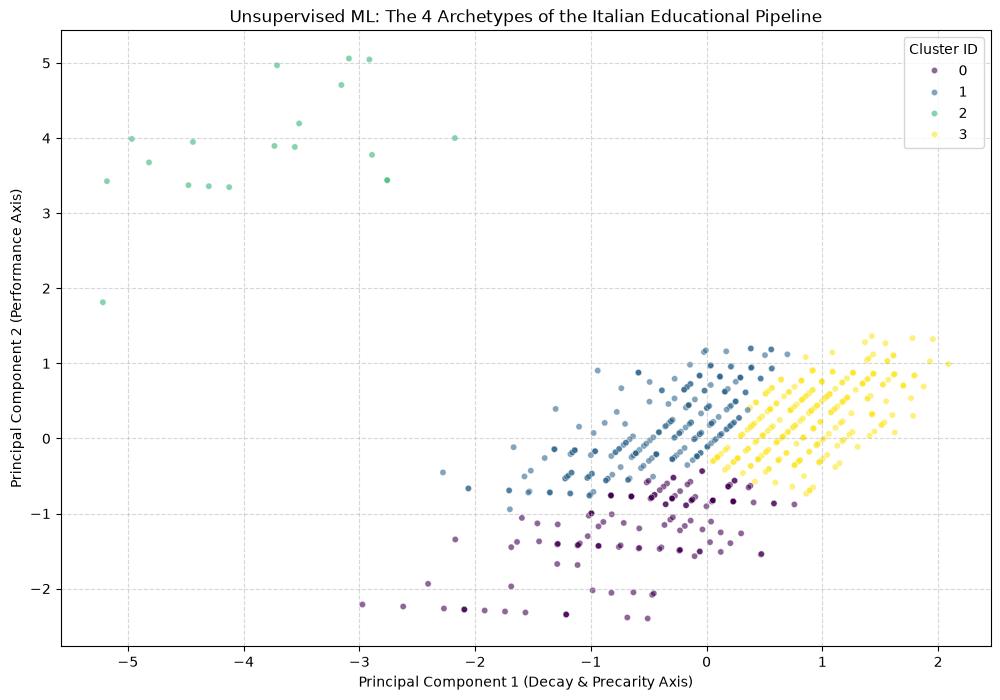

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='PCA_1', 
    y='PCA_2', 
    hue='Archetype_Cluster', 
    palette='viridis', 
    alpha=0.6, 
    s=20
)
plt.title('Unsupervised ML: The 4 Archetypes of the Italian Educational Pipeline')
plt.xlabel('Principal Component 1 (Decay & Precarity Axis)')
plt.ylabel('Principal Component 2 (Performance Axis)')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(ROOT / 'local_data/processed/archetypes_clustering_pca.png', bbox_inches='tight')
plt.show()


### Conclusion
By mapping these archetypes, we mathematically validate that the system is not monolithic. A student's destiny is largely determined by which of these 4 archetypal environments they are born into.
